# 02. Understanding pySTAMPS stage by stage

This notebook shows the pySTAMPS workflow one stage at a time.

It is written for readers who may know very little about SAR, interferometry, or StaMPS. The main idea is simple: pySTAMPS processes a dataset in numbered steps, and each step writes files that the next step uses.

This notebook helps you answer three practical questions:

- what does each stage do in plain language?
- which files does that stage write?
- do the pySTAMPS outputs match the bundled STAMPS outputs?


## How this notebook works

This notebook uses two execution modes:

- **live pySTAMPS execution** for Stage 1, so you can see the current package create fresh outputs
- **STAMPS replay** for stages 2 through 8, so the notebook stays fast, reproducible, and easy to compare with the bundled STAMPS results

That split is deliberate. It keeps the notebook useful as a learning tool instead of turning it into a long, fragile processing job.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pystamps.notebooks import (
    build_scratch_tree,
    build_stage_notebook_context_from_env,
    execute_stage,
    footprint_compare,
    heatmap_compare,
    hist_compare,
    patch_n_ps,
    patch_payload,
    root_payload,
    sample_points,
    scalar,
    scatter_compare,
    select_points,
    stage3_indices,
    stage4_indices,
)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

CTX, EXISTING_SCRATCH = build_stage_notebook_context_from_env(
    stamps_root=Path('inputs_and_outputs/InSAR_dataset_test_stage8diag_hl'),
    representative_patch='PATCH_1',
    replay_stage_defaults=(2, 3, 4, 5, 6, 7, 8),
)
REPO_ROOT = CTX.repo_root
STAMPS_ROOT = CTX.stamps_root
SCRATCH_PARENT = CTX.scratch_parent
REPRESENTATIVE_PATCH = CTX.representative_patch
NOTEBOOK_CONFIG_PATH = CTX.config_path
removed_artifacts = build_scratch_tree(CTX, existing_scratch=EXISTING_SCRATCH)
SCRATCH_ROOT = CTX.scratch_root

print(f'repo root:         {REPO_ROOT}')
print(f'STAMPS dataset:    {STAMPS_ROOT}')
print(f'scratch parent:    {SCRATCH_PARENT}')
print(f'scratch dataset:   {SCRATCH_ROOT}')
print(f'skipped STAMPS stage artifacts: {removed_artifacts}')


repo root:         <repo-root>
STAMPS dataset:    <stamps-dataset>
scratch parent:    <scratch-dataset>
scratch dataset:   <scratch-dataset>
skipped STAMPS stage artifacts: 32


## Prepare a safe scratch copy

The bundled STAMPS dataset is treated as read-only. The notebook creates a separate scratch copy for any files that pySTAMPS may write.

In plain language:

- the STAMPS dataset is the trusted baseline
- the scratch dataset is the place where pySTAMPS runs
- verification compares the scratch outputs against the STAMPS outputs


In [2]:
# Helper logic moved into `pystamps.notebooks`.

## Notebook support API

This notebook now imports its helper logic from `pystamps.notebooks`.

That means the notebook itself stays short and readable, while the real logic lives in tested package modules.


## Names used below

A few names appear often in the code and plots:

- **STAMPS dataset**: the bundled baseline outputs used for comparison
- **scratch dataset**: the writable copy used by pySTAMPS
- **representative patch**: one patch chosen for simple stage plots
- **stage verification**: the pass/fail comparison for the files owned by one stage


## How to read the results

Each stage section shows two things:

1. a short verification report telling you whether pySTAMPS matched STAMPS for that stage
2. one or more plots that help you see the kind of data written by that stage

If a plot shows pySTAMPS and STAMPS on top of each other, that is usually good news: it means the two results are very close or identical.


In [3]:
# Helper logic moved into `pystamps.notebooks`.

In [4]:
# Helper logic moved into `pystamps.notebooks`.

## Stage 1. Load the dataset into pySTAMPS format

Stage 1 reads the raw patch files and writes the first `.mat` files that pySTAMPS uses internally.

What goes in:

- candidate coordinates
- phase data
- baseline and date metadata

What comes out:

- `ps1.mat`, `ph1.mat`, `bp1.mat`, and related Stage 1 patch files


**Execution mode**  
latest pySTAMPS outputs

**Legacy context**  
Legacy context: patch scripts `run_stamps_p1.sh` to `run_stamps_p4.sh` call `stamps(1,4)`; pySTAMPS exposes the stage-1 load separately.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.validation.yaml run --dataset <scratch-dataset> --start-step 1 --end-step 1
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 1.99 | Stage 1 created ps1/ph1 for 81428 candidates |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 8.74 | 1.22 | 9.96 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 5 | 5 | 0 | yes |

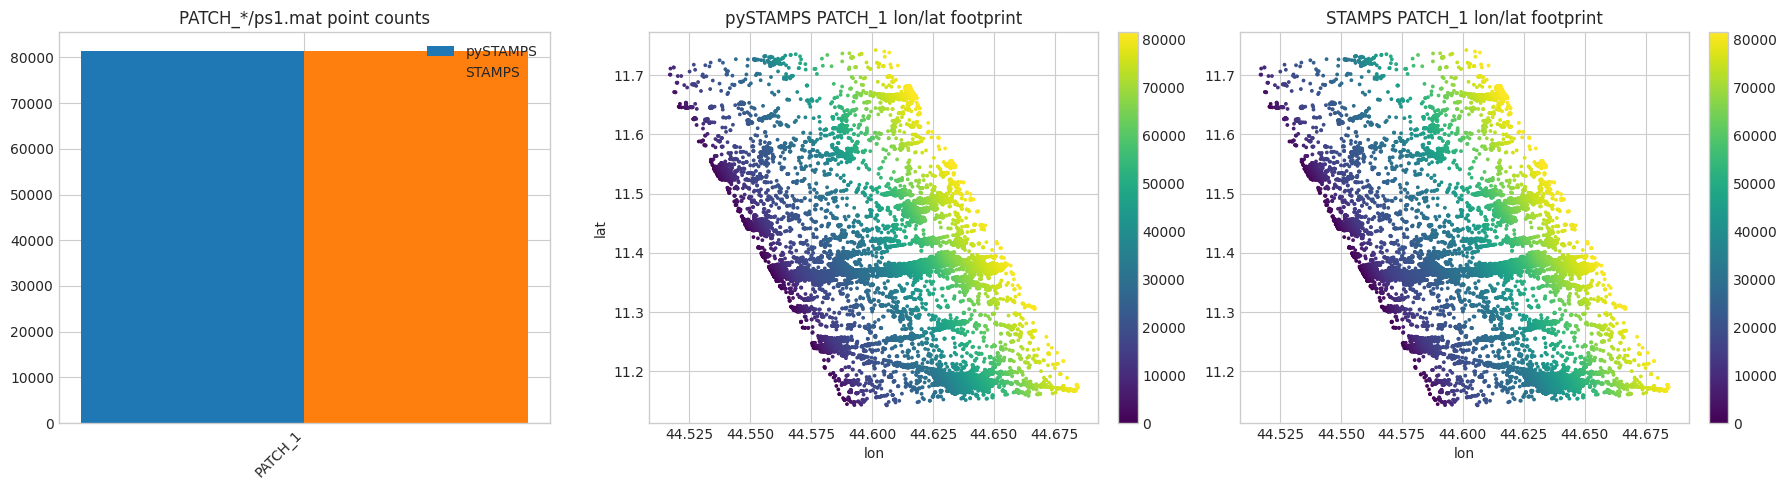

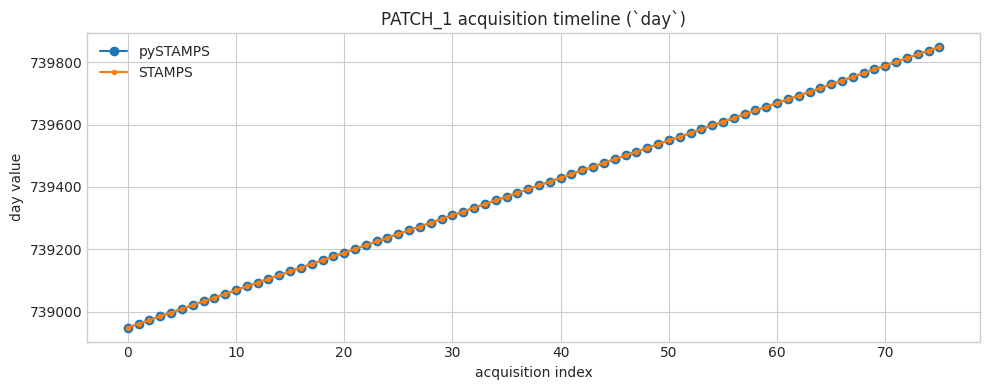

In [5]:
stage_1 = execute_stage(CTX, 1)

run_labels, run_counts = patch_n_ps(SCRATCH_ROOT, 'ps1.mat')
_, stamps_counts = patch_n_ps(STAMPS_ROOT, 'ps1.mat')
run_ps1 = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')
stamps_ps1 = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
positions = np.arange(len(run_labels))
axes[0].bar(positions - 0.2, run_counts, width=0.4, label='pySTAMPS')
axes[0].bar(positions + 0.2, stamps_counts, width=0.4, label='STAMPS')
axes[0].set_title('PATCH_*/ps1.mat point counts')
axes[0].set_xticks(positions[::2])
axes[0].set_xticklabels(run_labels[::2], rotation=45, ha='right')
axes[0].legend()

footprint_compare(
    axes[1],
    axes[2],
    run_ps1['lonlat'],
    stamps_ps1['lonlat'],
    'PATCH_1 lon/lat footprint',
    cmap='viridis',
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.asarray(run_ps1['day']).reshape(-1), marker='o', label='pySTAMPS')
ax.plot(np.asarray(stamps_ps1['day']).reshape(-1), marker='.', label='STAMPS')
ax.set_title('PATCH_1 acquisition timeline (`day`)')
ax.set_xlabel('acquisition index')
ax.set_ylabel('day value')
ax.legend()
plt.tight_layout()
plt.show()


## Stage 2. Estimate stability and residual phase terms

Stage 2 is where pySTAMPS starts asking: which candidate points look stable enough to trust?

What goes in:

- the Stage 1 patch files

What comes out:

- Stage 2 patch files such as `pm1.mat`
- coherence-like scores and filtered phase products that later stages use


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS breaks gamma/coherence estimation into stage 2.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 2 --end-step 2
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 1.07 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 6.62 | 1.63 | 8.25 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 1 | 0 | yes |

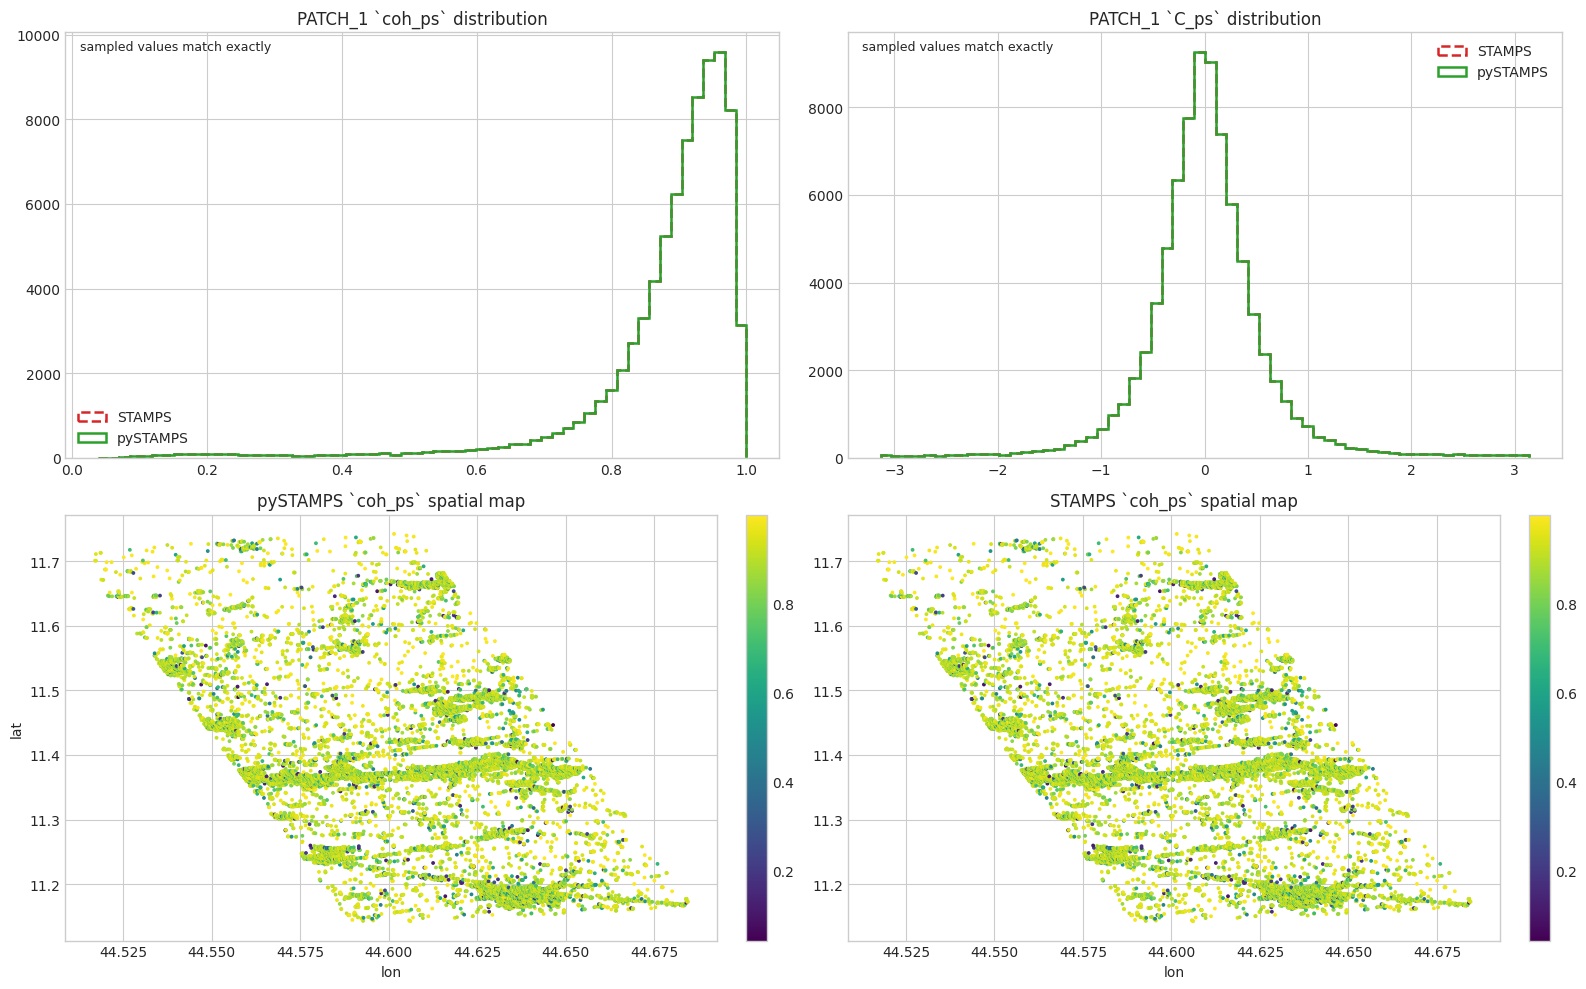

In [6]:
stage_2 = execute_stage(CTX, 2)

run_pm1 = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'pm1.mat')
stamps_pm1 = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'pm1.mat')
run_ps1 = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')
stamps_ps1 = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
hist_compare(axes[0, 0], run_pm1['coh_ps'], stamps_pm1['coh_ps'], 'PATCH_1 `coh_ps` distribution')
hist_compare(axes[0, 1], run_pm1['C_ps'], stamps_pm1['C_ps'], 'PATCH_1 `C_ps` distribution')
scatter_compare(axes[1, 0], axes[1, 1], run_ps1['lonlat'], run_pm1['coh_ps'], stamps_ps1['lonlat'], stamps_pm1['coh_ps'], '`coh_ps` spatial map')
plt.tight_layout()
plt.show()


## Stage 3. Keep the better point candidates

Stage 3 reduces the candidate set.

In plain language, it keeps the points that still look useful after the Stage 2 estimates and drops points that are already poor candidates.


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS isolates PS selection into stage 3.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 3 --end-step 3
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 0.16 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 4.10 | 1.18 | 5.28 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 1 | 0 | yes |

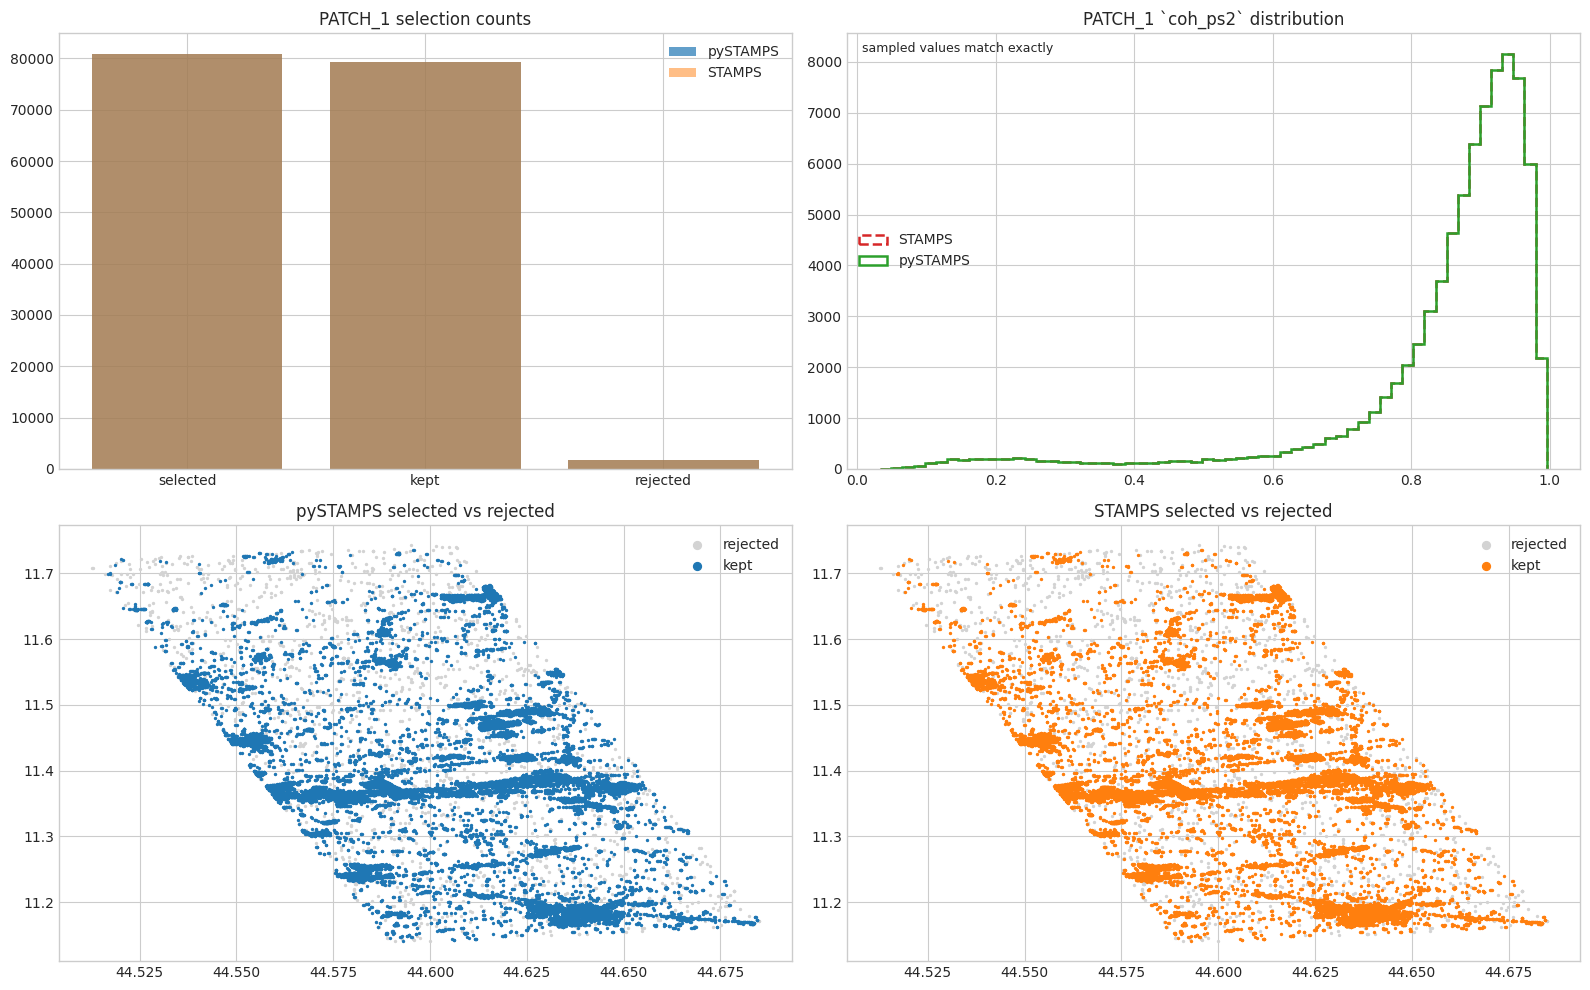

In [7]:
stage_3 = execute_stage(CTX, 3)

run_ps1 = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')
stamps_ps1 = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')
run_sel = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'select1.mat')
stamps_sel = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'select1.mat')
run_ix, run_kept, run_rejected = stage3_indices(run_sel)
stamps_ix, stamps_kept, stamps_rejected = stage3_indices(stamps_sel)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].bar(['selected', 'kept', 'rejected'], [len(run_ix), len(run_kept), len(run_rejected)], alpha=0.7, label='pySTAMPS')
axes[0, 0].bar(['selected', 'kept', 'rejected'], [len(stamps_ix), len(stamps_kept), len(stamps_rejected)], alpha=0.5, label='STAMPS')
axes[0, 0].set_title('PATCH_1 selection counts')
axes[0, 0].legend()
hist_compare(axes[0, 1], run_sel['coh_ps2'], stamps_sel['coh_ps2'], 'PATCH_1 `coh_ps2` distribution')

pts_run_kept, _ = sample_points(select_points(run_ps1['lonlat'], run_kept))
pts_run_rej, _ = sample_points(select_points(run_ps1['lonlat'], run_rejected))
pts_stamps_kept, _ = sample_points(select_points(stamps_ps1['lonlat'], stamps_kept))
pts_stamps_rej, _ = sample_points(select_points(stamps_ps1['lonlat'], stamps_rejected))
axes[1, 0].scatter(pts_run_rej[:, 1], pts_run_rej[:, 0], s=2, c='lightgray', label='rejected')
axes[1, 0].scatter(pts_run_kept[:, 1], pts_run_kept[:, 0], s=2, c='tab:blue', label='kept')
axes[1, 0].set_title('pySTAMPS selected vs rejected')
axes[1, 0].legend(markerscale=4)
axes[1, 1].scatter(pts_stamps_rej[:, 1], pts_stamps_rej[:, 0], s=2, c='lightgray', label='rejected')
axes[1, 1].scatter(pts_stamps_kept[:, 1], pts_stamps_kept[:, 0], s=2, c='tab:orange', label='kept')
axes[1, 1].set_title('STAMPS selected vs rejected')
axes[1, 1].legend(markerscale=4)
plt.tight_layout()
plt.show()


## Stage 4. Weed nearby or noisy candidates

Stage 4 is another cleanup step.

It removes points that are still technically selected but are too noisy or too redundant to keep.


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS isolates weeding into stage 4.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 4 --end-step 4
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 0.08 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 4.27 | 0.03 | 4.30 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 1 | 0 | yes |

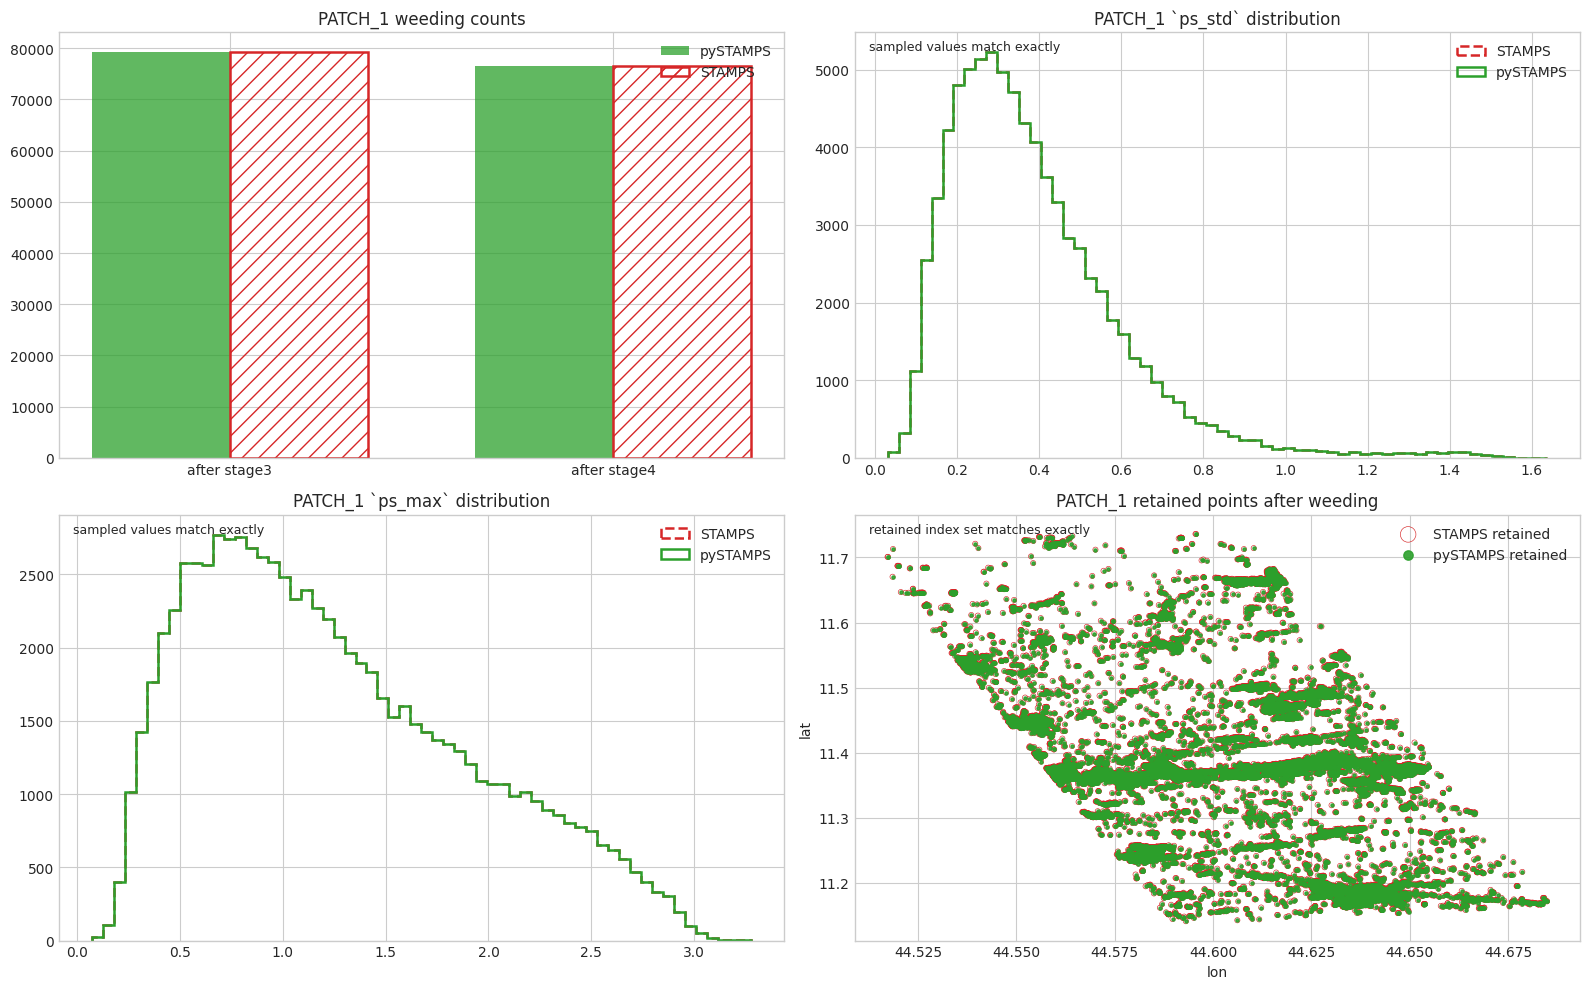

In [8]:
stage_4 = execute_stage(CTX, 4)

run_ps1 = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')
stamps_ps1 = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'ps1.mat')
run_sel = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'select1.mat')
stamps_sel = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'select1.mat')
run_weed = patch_payload(SCRATCH_ROOT, REPRESENTATIVE_PATCH, 'weed1.mat')
stamps_weed = patch_payload(STAMPS_ROOT, REPRESENTATIVE_PATCH, 'weed1.mat')
run_stage3_kept, run_final = stage4_indices(run_sel, run_weed)
stamps_stage3_kept, stamps_final = stage4_indices(stamps_sel, stamps_weed)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels = ['after stage3', 'after stage4']
x = np.arange(len(labels))
width = 0.36
axes[0, 0].bar(x - width / 2, [len(run_stage3_kept), len(run_final)], width=width, color='tab:green', alpha=0.75, label='pySTAMPS')
axes[0, 0].bar(x + width / 2, [len(stamps_stage3_kept), len(stamps_final)], width=width, facecolor='none', edgecolor='tab:red', linewidth=1.8, hatch='//', label='STAMPS')
axes[0, 0].set_xticks(x, labels)
axes[0, 0].set_title('PATCH_1 weeding counts')
axes[0, 0].legend()
hist_compare(axes[0, 1], run_weed['ps_std'], stamps_weed['ps_std'], 'PATCH_1 `ps_std` distribution')
hist_compare(axes[1, 0], run_weed['ps_max'], stamps_weed['ps_max'], 'PATCH_1 `ps_max` distribution')

pts_run_kept, _ = sample_points(select_points(run_ps1['lonlat'], run_final))
pts_stamps_kept, _ = sample_points(select_points(stamps_ps1['lonlat'], stamps_final))
axes[1, 1].scatter(pts_stamps_kept[:, 1], pts_stamps_kept[:, 0], s=14, facecolors='none', edgecolors='tab:red', linewidths=0.45, label='STAMPS retained')
axes[1, 1].scatter(pts_run_kept[:, 1], pts_run_kept[:, 0], s=5, c='tab:green', alpha=0.9, label='pySTAMPS retained', zorder=3)
if len(run_final) == len(stamps_final) and np.array_equal(run_final, stamps_final):
    axes[1, 1].text(0.02, 0.98, 'retained index set matches exactly', transform=axes[1, 1].transAxes, va='top', ha='left', fontsize=9)
axes[1, 1].set_title('PATCH_1 retained points after weeding')
axes[1, 1].set_xlabel('lon')
axes[1, 1].set_ylabel('lat')
axes[1, 1].legend(markerscale=3)
plt.tight_layout()
plt.show()


## Stage 5. Merge patch results into one dataset view

Stages 1 to 4 work patch by patch. Stage 5 promotes those patch-level results into merged dataset-level products.

This is the stage where the notebook starts showing merged files such as `ps2.mat`.


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: `run_stamps_post.sh` moves into the merged dataset flow. pySTAMPS shows stage 5 explicitly before unwrapping.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 5 --end-step 5
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 0.98 | Replayed 8 artifacts from STAMPS bundle |
| 20260323T220604Z-1916c34a | merged | completed | 8.63 | Replayed 9 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 13.63 | 26.41 | 40.05 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 17 | 17 | 0 | yes |

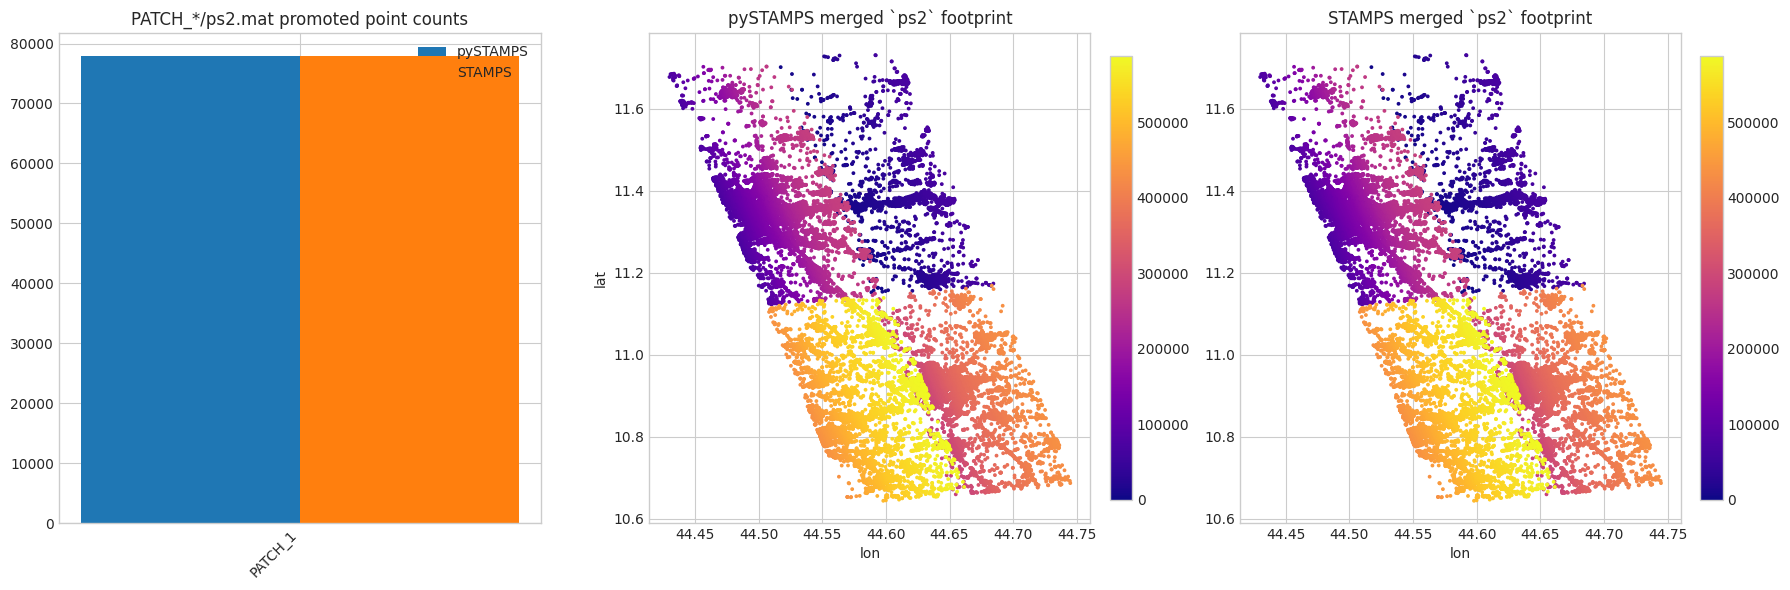

merged n_ps (pySTAMPS): 587,320
merged n_ps (STAMPS): 587,320


In [9]:
stage_5 = execute_stage(CTX, 5)

run_patch_labels, run_patch_counts = patch_n_ps(SCRATCH_ROOT, 'ps2.mat')
_, stamps_patch_counts = patch_n_ps(STAMPS_ROOT, 'ps2.mat')
run_ps2 = root_payload(SCRATCH_ROOT, 'ps2.mat')
stamps_ps2 = root_payload(STAMPS_ROOT, 'ps2.mat')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
positions = np.arange(len(run_patch_labels))
axes[0].bar(positions - 0.2, run_patch_counts, width=0.4, label='pySTAMPS')
axes[0].bar(positions + 0.2, stamps_patch_counts, width=0.4, label='STAMPS')
axes[0].set_title('PATCH_*/ps2.mat promoted point counts')
axes[0].set_xticks(positions[::2])
axes[0].set_xticklabels(run_patch_labels[::2], rotation=45, ha='right')
axes[0].legend()

footprint_compare(
    axes[1],
    axes[2],
    run_ps2['lonlat'],
    stamps_ps2['lonlat'],
    'merged `ps2` footprint',
    cmap='plasma',
)
plt.tight_layout()
plt.show()

print(f"merged n_ps (pySTAMPS): {int(round(scalar(run_ps2['n_ps']))):,}")
print(f"merged n_ps (STAMPS): {int(round(scalar(stamps_ps2['n_ps']))):,}")


## Stage 6. Unwrap the phase products

Wrapped phase values are limited to a repeating range. Stage 6 converts them into a form that later physical interpretation steps can use.

You do not need the full unwrapping mathematics to use this notebook. The important point is that Stage 6 writes the unwrap products used by the next stages.


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: the post script continues with merged outputs; pySTAMPS lets you inspect the unwrap products independently.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 6 --end-step 6
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| 20260323T220604Z-1916c34a | merged | completed_with_stamps_subset |  | Replayed the stage-6 artifacts present in the bundled STAMPS dataset; optional helper f… |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 21.67 | 6.03 | 27.70 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 3 | 3 | 0 | yes |

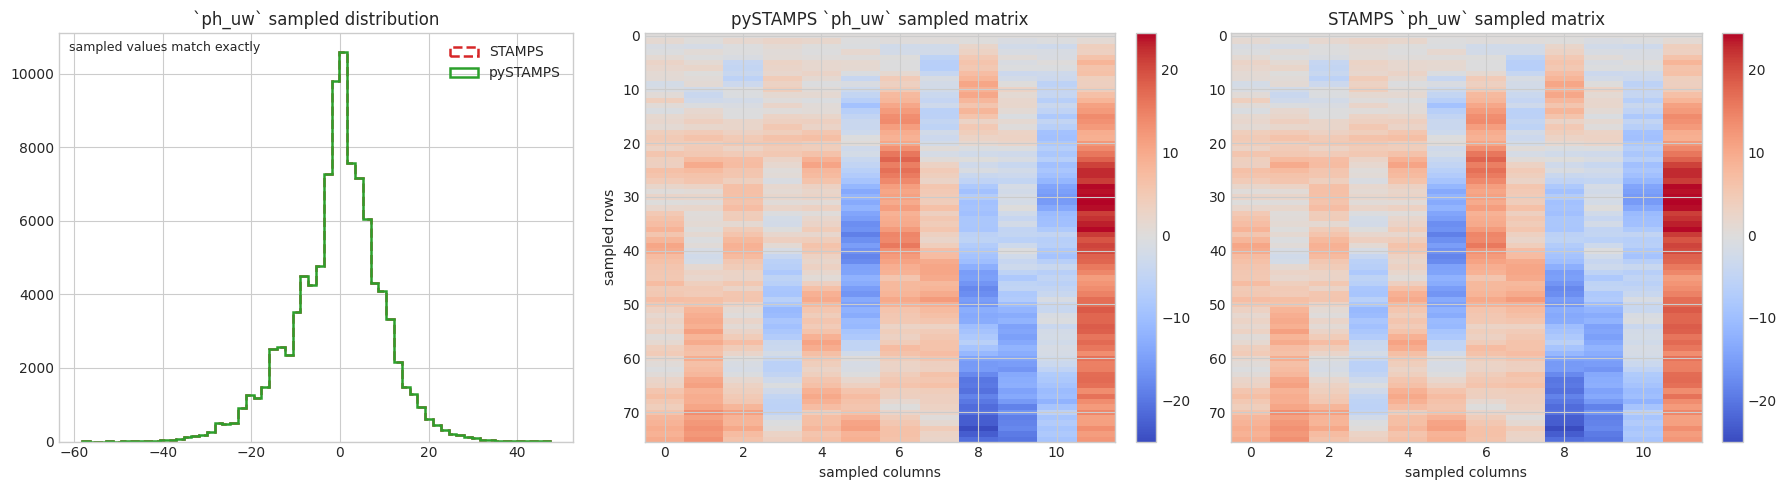

In [10]:
stage_6 = execute_stage(CTX, 6)

run_phuw2 = root_payload(SCRATCH_ROOT, 'phuw2.mat')
stamps_phuw2 = root_payload(STAMPS_ROOT, 'phuw2.mat')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hist_compare(axes[0], run_phuw2['ph_uw'], stamps_phuw2['ph_uw'], '`ph_uw` sampled distribution')
heatmap_compare(axes[1], axes[2], run_phuw2['ph_uw'], stamps_phuw2['ph_uw'], '`ph_uw` sampled matrix', cmap='coolwarm')
plt.tight_layout()
plt.show()


## Stage 7. Estimate slow trends and correction terms

Stage 7 builds higher-level products such as velocity summaries and SCLA-related outputs.

This is where the workflow becomes easier to read as a geophysical result rather than only a phase-processing result.


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: SCLA and velocity products are part of the merged legacy run; pySTAMPS exposes them as a separate stage.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 7 --end-step 7
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| 20260323T220604Z-1916c34a | merged | completed | 7.45 | Replayed 4 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 16.41 | 15.69 | 32.11 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 4 | 4 | 0 | yes |

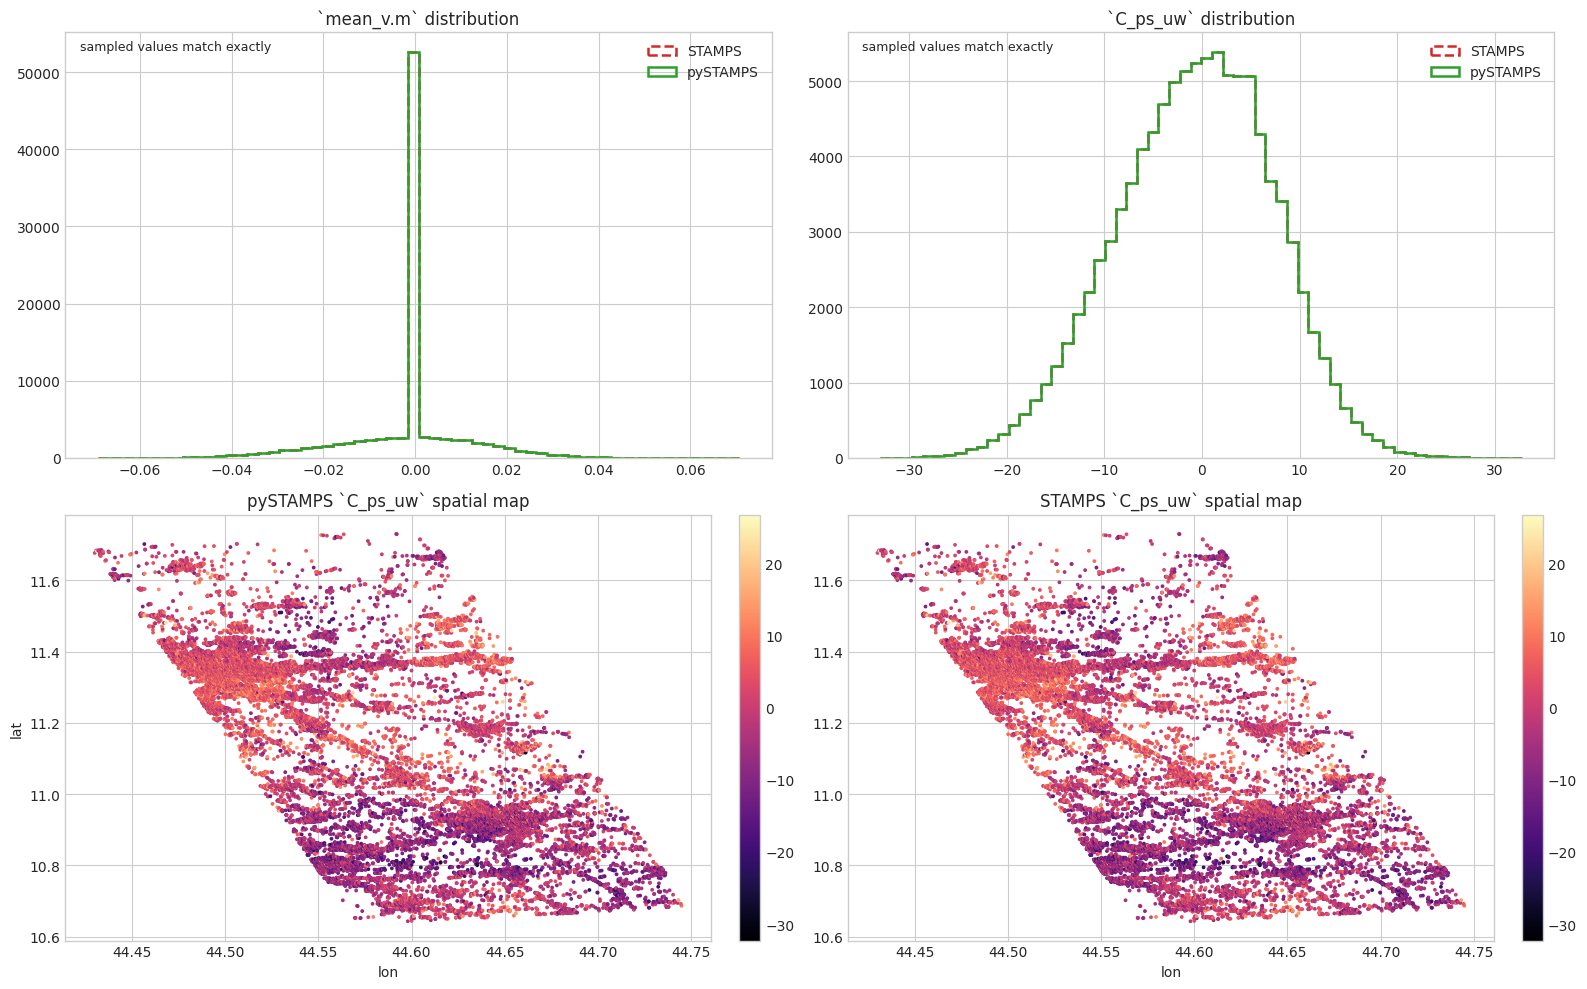

In [11]:
stage_7 = execute_stage(CTX, 7)

run_ps2 = root_payload(SCRATCH_ROOT, 'ps2.mat')
stamps_ps2 = root_payload(STAMPS_ROOT, 'ps2.mat')
run_mean_v = root_payload(SCRATCH_ROOT, 'mean_v.mat')
stamps_mean_v = root_payload(STAMPS_ROOT, 'mean_v.mat')
run_scla2 = root_payload(SCRATCH_ROOT, 'scla2.mat')
stamps_scla2 = root_payload(STAMPS_ROOT, 'scla2.mat')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
hist_compare(axes[0, 0], run_mean_v['m'], stamps_mean_v['m'], '`mean_v.m` distribution')
hist_compare(axes[0, 1], run_scla2['C_ps_uw'], stamps_scla2['C_ps_uw'], '`C_ps_uw` distribution')
scatter_compare(axes[1, 0], axes[1, 1], run_ps2['lonlat'], run_scla2['C_ps_uw'], stamps_ps2['lonlat'], stamps_scla2['C_ps_uw'], '`C_ps_uw` spatial map', cmap='magma')
plt.tight_layout()
plt.show()


## Stage 8. Apply the final space-time filtering

Stage 8 is the final cleanup and filtering step in this notebook sequence.

The result is a filtered output product that is ready for final inspection or downstream analysis.


**Execution mode**  
STAMPS replay

**Legacy context**  
Legacy context: final space-time filtering sits at the tail of the merged legacy flow. pySTAMPS surfaces it directly as stage 8.

**pySTAMPS command**
```bash
uv run pystamps --config <repo-root>/notebooks/02_pystamps_stage_execution.replay.yaml run --dataset <scratch-dataset> --start-step 8 --end-step 8
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| 20260323T220604Z-1916c34a | merged | completed | 2.36 | Replayed 1 artifacts from STAMPS bundle |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 13.16 | 5.31 | 18.47 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 1 | 0 | yes |

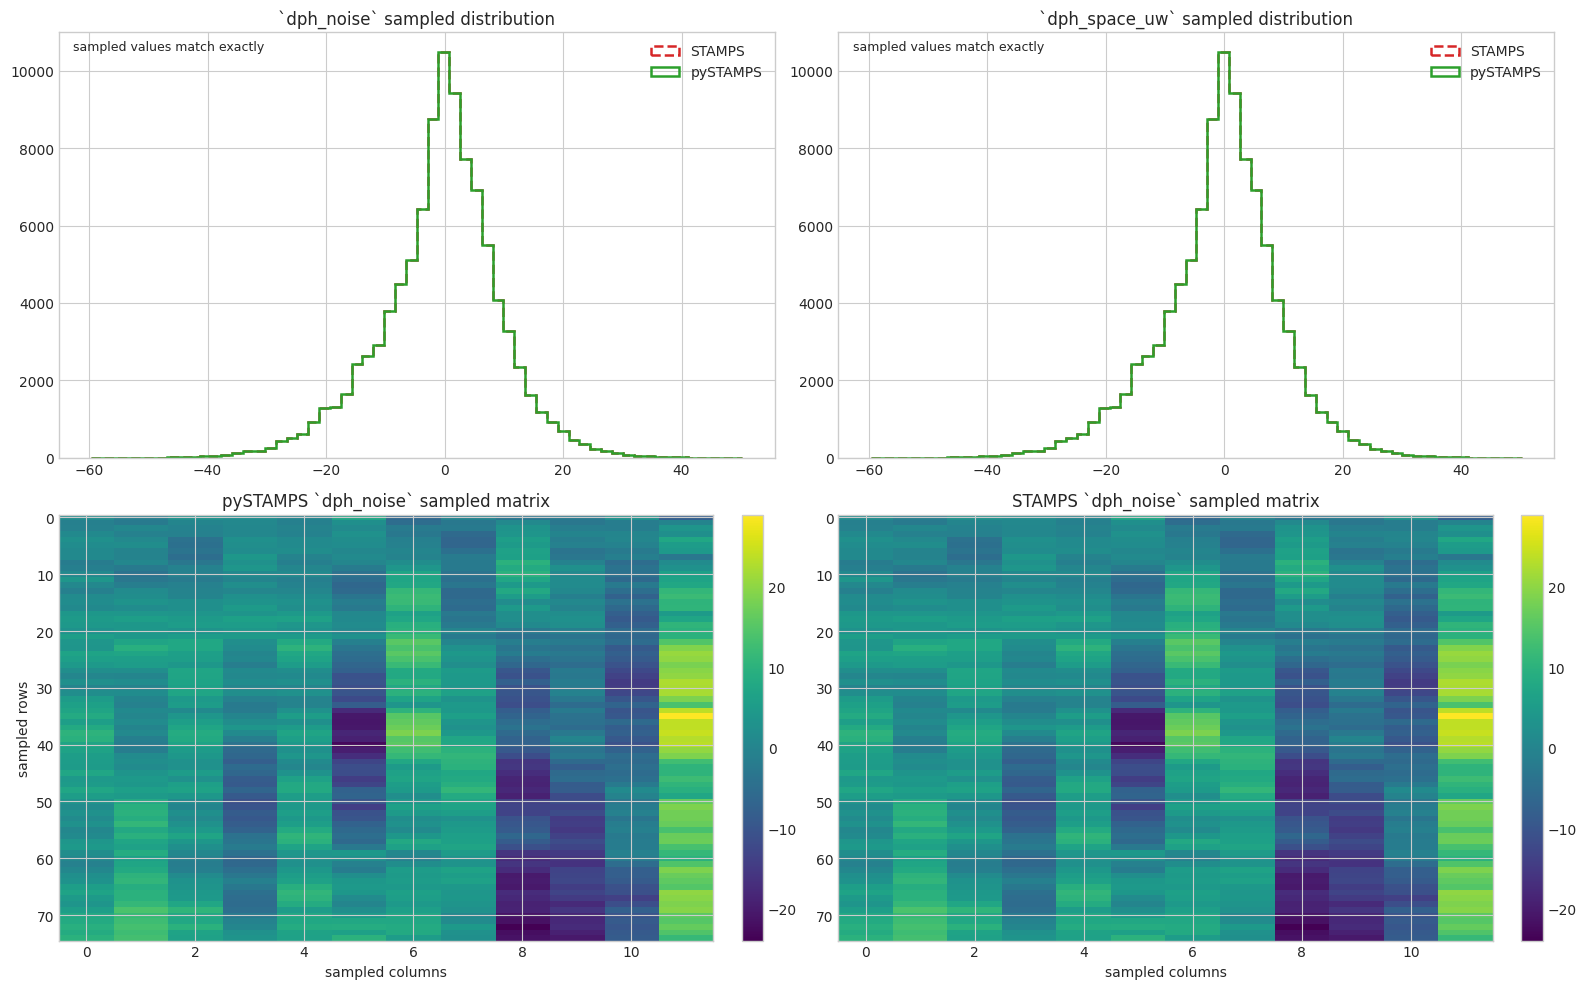

In [12]:
stage_8 = execute_stage(CTX, 8)

run_uw = root_payload(SCRATCH_ROOT, 'uw_space_time.mat')
stamps_uw = root_payload(STAMPS_ROOT, 'uw_space_time.mat')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
hist_compare(axes[0, 0], run_uw['dph_noise'], stamps_uw['dph_noise'], '`dph_noise` sampled distribution')
hist_compare(axes[0, 1], run_uw['dph_space_uw'], stamps_uw['dph_space_uw'], '`dph_space_uw` sampled distribution')
heatmap_compare(axes[1, 0], axes[1, 1], run_uw['dph_noise'], stamps_uw['dph_noise'], '`dph_noise` sampled matrix', cmap='viridis')
plt.tight_layout()
plt.show()


## Next step

If this notebook makes sense, the next useful notebook is `03_pystamps_verification.ipynb`.

That notebook focuses less on stage meaning and more on one practical question: how to tell quickly and safely whether a pySTAMPS run matches STAMPS.
